# Model Comparison and Final Model Selection

## Hotel Booking Cancellation Prediction

This notebook performs the final systematic comparison of the four candidate machine-learning models developed for the project:

1. Logistic Regression
2. Decision Tree
3. Random Forest
4. XGBoost

The models are compared using the common evaluation criteria used throughout the modelling stage, including:

- Cross-validation performance
- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC
- Confusion Matrix results
- Generalization between cross-validation and hold-out testing
- Model complexity and deployment considerations

No models are retrained in this notebook. The comparison uses the result files generated during the individual model-development stages.

The objective is to select and justify the most suitable final model for deployment.

## 1. Import Required Libraries

The required libraries are imported for loading the individual model result files, combining the results, performing comparative analysis, and creating model-comparison visualizations.

No machine-learning models are retrained in this notebook.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 2. Load Individual Model Results

The final result files produced by the four model-development stages are loaded.

These files contain the cross-validation and hold-out test results of:

- Logistic Regression
- Decision Tree
- Random Forest
- XGBoost

The original result files are preserved without modification.

In [2]:
logistic_results = pd.read_csv(
    "../results/logistic_regression_results.csv"
)

decision_tree_results = pd.read_csv(
    "../results/decision_tree_results.csv"
)

random_forest_results = pd.read_csv(
    "../results/random_forest_results.csv"
)

xgboost_results = pd.read_csv(
    "../results/xgboost_results.csv"
)

print("All four model result files loaded successfully.")

All four model result files loaded successfully.


## 3. Verify the Result Files

Before combining the results, the structure of each model result file is inspected.

This is important because the individual model result files may contain some model-specific columns in addition to the common evaluation metrics.

In [3]:
print(
    "Logistic Regression:",
    logistic_results.shape
)

print(
    "Decision Tree:",
    decision_tree_results.shape
)

print(
    "Random Forest:",
    random_forest_results.shape
)

print(
    "XGBoost:",
    xgboost_results.shape
)

Logistic Regression: (1, 20)
Decision Tree: (1, 34)
Random Forest: (1, 28)
XGBoost: (1, 32)


## 4. Inspect Result File Columns

The four result files contain different numbers of columns because each model stores model-specific information such as hyperparameters, runtime measurements, and additional diagnostic values.

Before combining the model results, the column names are inspected to identify the common evaluation metrics that can be compared fairly across all four models.

In [4]:
print("LOGISTIC REGRESSION COLUMNS")
print(logistic_results.columns.tolist())

print("\nDECISION TREE COLUMNS")
print(decision_tree_results.columns.tolist())

print("\nRANDOM FOREST COLUMNS")
print(random_forest_results.columns.tolist())

print("\nXGBOOST COLUMNS")
print(xgboost_results.columns.tolist())

LOGISTIC REGRESSION COLUMNS
['Member', 'Model', 'Best_C', 'Best_Class_Weight', 'Best_Penalty', 'Best_Solver', 'CV_Accuracy', 'CV_Precision', 'CV_Recall', 'CV_F1', 'CV_ROC_AUC', 'Test_Accuracy', 'Test_Precision', 'Test_Recall', 'Test_F1', 'Test_ROC_AUC', 'TN', 'FP', 'FN', 'TP']

DECISION TREE COLUMNS
['member', 'model', 'version', 'best_criterion', 'best_max_depth', 'best_min_samples_split', 'best_min_samples_leaf', 'best_class_weight', 'cv_accuracy_mean', 'cv_accuracy_std', 'cv_precision_mean', 'cv_precision_std', 'cv_recall_mean', 'cv_recall_std', 'cv_f1_mean', 'cv_f1_std', 'cv_roc_auc_mean', 'cv_roc_auc_std', 'final_test_accuracy', 'final_test_precision', 'final_test_recall', 'final_test_f1', 'final_test_roc_auc', 'tn', 'fp', 'fn', 'tp', 'baseline_cv_time_seconds', 'tuning_time_seconds', 'tuned_cv_time_seconds', 'main_strength', 'main_weakness', 'overfitting_observation', 'recommend_as_final_candidate']

RANDOM FOREST COLUMNS
['member', 'model', 'version', 'best_n_estimators', 'best_

## 5. Standardize Common Evaluation Metrics

The four model result files use different column naming conventions because they were created independently during model development.

The original CSV files are not modified.

Instead, the common cross-validation and hold-out test metrics are extracted from each result file and standardized into a single comparison table.

The following common metrics are used:

- CV Accuracy
- CV Precision
- CV Recall
- CV F1-score
- CV ROC-AUC
- Test Accuracy
- Test Precision
- Test Recall
- Test F1-score
- Test ROC-AUC
- True Negatives
- False Positives
- False Negatives
- True Positives

In [5]:
comparison_data = [
    {
        "Model": "Logistic Regression",
        "CV_Accuracy": logistic_results.loc[0, "CV_Accuracy"],
        "CV_Precision": logistic_results.loc[0, "CV_Precision"],
        "CV_Recall": logistic_results.loc[0, "CV_Recall"],
        "CV_F1": logistic_results.loc[0, "CV_F1"],
        "CV_ROC_AUC": logistic_results.loc[0, "CV_ROC_AUC"],
        "Test_Accuracy": logistic_results.loc[0, "Test_Accuracy"],
        "Test_Precision": logistic_results.loc[0, "Test_Precision"],
        "Test_Recall": logistic_results.loc[0, "Test_Recall"],
        "Test_F1": logistic_results.loc[0, "Test_F1"],
        "Test_ROC_AUC": logistic_results.loc[0, "Test_ROC_AUC"],
        "TN": logistic_results.loc[0, "TN"],
        "FP": logistic_results.loc[0, "FP"],
        "FN": logistic_results.loc[0, "FN"],
        "TP": logistic_results.loc[0, "TP"]
    },

    {
        "Model": "Decision Tree",
        "CV_Accuracy": decision_tree_results.loc[0, "cv_accuracy_mean"],
        "CV_Precision": decision_tree_results.loc[0, "cv_precision_mean"],
        "CV_Recall": decision_tree_results.loc[0, "cv_recall_mean"],
        "CV_F1": decision_tree_results.loc[0, "cv_f1_mean"],
        "CV_ROC_AUC": decision_tree_results.loc[0, "cv_roc_auc_mean"],
        "Test_Accuracy": decision_tree_results.loc[0, "final_test_accuracy"],
        "Test_Precision": decision_tree_results.loc[0, "final_test_precision"],
        "Test_Recall": decision_tree_results.loc[0, "final_test_recall"],
        "Test_F1": decision_tree_results.loc[0, "final_test_f1"],
        "Test_ROC_AUC": decision_tree_results.loc[0, "final_test_roc_auc"],
        "TN": decision_tree_results.loc[0, "tn"],
        "FP": decision_tree_results.loc[0, "fp"],
        "FN": decision_tree_results.loc[0, "fn"],
        "TP": decision_tree_results.loc[0, "tp"]
    },

    {
        "Model": "Random Forest",
        "CV_Accuracy": random_forest_results.loc[0, "cv_accuracy_mean"],
        "CV_Precision": random_forest_results.loc[0, "cv_precision_mean"],
        "CV_Recall": random_forest_results.loc[0, "cv_recall_mean"],
        "CV_F1": random_forest_results.loc[0, "cv_f1_mean"],
        "CV_ROC_AUC": random_forest_results.loc[0, "cv_roc_auc_mean"],
        "Test_Accuracy": random_forest_results.loc[0, "test_accuracy"],
        "Test_Precision": random_forest_results.loc[0, "test_precision"],
        "Test_Recall": random_forest_results.loc[0, "test_recall"],
        "Test_F1": random_forest_results.loc[0, "test_f1"],
        "Test_ROC_AUC": random_forest_results.loc[0, "test_roc_auc"],
        "TN": random_forest_results.loc[0, "TN"],
        "FP": random_forest_results.loc[0, "FP"],
        "FN": random_forest_results.loc[0, "FN"],
        "TP": random_forest_results.loc[0, "TP"]
    },

    {
        "Model": "XGBoost",
        "CV_Accuracy": xgboost_results.loc[0, "cv_accuracy_mean"],
        "CV_Precision": xgboost_results.loc[0, "cv_precision_mean"],
        "CV_Recall": xgboost_results.loc[0, "cv_recall_mean"],
        "CV_F1": xgboost_results.loc[0, "cv_f1_mean"],
        "CV_ROC_AUC": xgboost_results.loc[0, "cv_roc_auc_mean"],
        "Test_Accuracy": xgboost_results.loc[0, "final_test_accuracy"],
        "Test_Precision": xgboost_results.loc[0, "final_test_precision"],
        "Test_Recall": xgboost_results.loc[0, "final_test_recall"],
        "Test_F1": xgboost_results.loc[0, "final_test_f1"],
        "Test_ROC_AUC": xgboost_results.loc[0, "final_test_roc_auc"],
        "TN": xgboost_results.loc[0, "tn"],
        "FP": xgboost_results.loc[0, "fp"],
        "FN": xgboost_results.loc[0, "fn"],
        "TP": xgboost_results.loc[0, "tp"]
    }
]

comparison_df = pd.DataFrame(comparison_data)

comparison_df.round(4)

,Model,CV_Accuracy,CV_Precision,CV_Recall,CV_F1,CV_ROC_AUC,Test_Accuracy,Test_Precision,Test_Recall,Test_F1,Test_ROC_AUC,TN,FP,FN,TP
0,Logistic Regression,0.8142,0.7290,0.7934,0.7598,0.9007,0.8126,0.7294,0.7858,0.7565,0.8991,12454,2579,1895,6950
1,Decision Tree,0.8617,0.7840,0.8651,0.8225,0.9097,0.8663,0.7934,0.8641,0.8273,0.9134,13043,1990,1202,7643
2,Random Forest,0.8918,0.8565,0.8504,0.8534,0.9578,0.8963,0.8620,0.8574,0.8597,0.9599,13819,1214,1261,7584
3,XGBoost,0.8813,0.8569,0.8158,0.8358,0.9657,0.8925,0.8688,0.8358,0.8520,0.9611,13917,1116,1452,7393


## 6. Cross-Validation vs Hold-Out Test Generalization

Cross-validation performance is compared with final hold-out test performance to examine how consistently each model generalizes to unseen data.

A small difference between cross-validation and test performance suggests that the model behaves consistently across development and unseen hold-out data.

However, the gap alone is not used to select the final model. It is interpreted together with overall predictive performance, class-specific errors, and other evaluation criteria.

In [6]:
gap_df = comparison_df[
    [
        "Model",
        "CV_Accuracy",
        "Test_Accuracy",
        "CV_Precision",
        "Test_Precision",
        "CV_Recall",
        "Test_Recall",
        "CV_F1",
        "Test_F1",
        "CV_ROC_AUC",
        "Test_ROC_AUC"
    ]
].copy()

gap_df["Accuracy_Gap"] = (
    gap_df["Test_Accuracy"]
    - gap_df["CV_Accuracy"]
)

gap_df["Precision_Gap"] = (
    gap_df["Test_Precision"]
    - gap_df["CV_Precision"]
)

gap_df["Recall_Gap"] = (
    gap_df["Test_Recall"]
    - gap_df["CV_Recall"]
)

gap_df["F1_Gap"] = (
    gap_df["Test_F1"]
    - gap_df["CV_F1"]
)

gap_df["ROC_AUC_Gap"] = (
    gap_df["Test_ROC_AUC"]
    - gap_df["CV_ROC_AUC"]
)

gap_df[
    [
        "Model",
        "Accuracy_Gap",
        "Precision_Gap",
        "Recall_Gap",
        "F1_Gap",
        "ROC_AUC_Gap"
    ]
].round(4)


,Model,Accuracy_Gap,Precision_Gap,Recall_Gap,F1_Gap,ROC_AUC_Gap
0,Logistic Regression,-0.0016,0.0004,-0.0076,-0.0033,-0.0016
1,Decision Tree,0.0046,0.0094,-0.0010,0.0047,0.0037
2,Random Forest,0.0046,0.0056,0.0071,0.0063,0.0021
3,XGBoost,0.0112,0.0120,0.0201,0.0162,-0.0046


### Absolute Generalization Gap Analysis

The absolute difference between cross-validation and hold-out test performance is calculated for each evaluation metric.

This analysis focuses on the magnitude of the difference regardless of whether the test score is slightly higher or lower than the cross-validation score.

Smaller gaps generally indicate more consistent performance between model development and unseen hold-out testing.

However, generalization gap alone is not sufficient for final model selection and must be interpreted together with predictive performance and error analysis.

In [7]:
generalization_df = pd.DataFrame({
    "Model": comparison_df["Model"],

    "Accuracy_Gap": (
        comparison_df["Test_Accuracy"]
        - comparison_df["CV_Accuracy"]
    ).abs(),

    "Precision_Gap": (
        comparison_df["Test_Precision"]
        - comparison_df["CV_Precision"]
    ).abs(),

    "Recall_Gap": (
        comparison_df["Test_Recall"]
        - comparison_df["CV_Recall"]
    ).abs(),

    "F1_Gap": (
        comparison_df["Test_F1"]
        - comparison_df["CV_F1"]
    ).abs(),

    "ROC_AUC_Gap": (
        comparison_df["Test_ROC_AUC"]
        - comparison_df["CV_ROC_AUC"]
    ).abs()
})

generalization_df["Mean_Absolute_Gap"] = (
    generalization_df[
        [
            "Accuracy_Gap",
            "Precision_Gap",
            "Recall_Gap",
            "F1_Gap",
            "ROC_AUC_Gap"
        ]
    ].mean(axis=1)
)

generalization_df.round(4)

,Model,Accuracy_Gap,Precision_Gap,Recall_Gap,F1_Gap,ROC_AUC_Gap,Mean_Absolute_Gap
0,Logistic Regression,0.0016,0.0004,0.0076,0.0033,0.0016,0.0029
1,Decision Tree,0.0046,0.0094,0.0010,0.0047,0.0037,0.0047
2,Random Forest,0.0046,0.0056,0.0071,0.0063,0.0021,0.0051
3,XGBoost,0.0112,0.0120,0.0201,0.0162,0.0046,0.0128


## 7. Hold-Out Test Performance Comparison

The four candidate models are compared using their final hold-out test performance.

The hold-out test dataset represents unseen data that was not used for hyperparameter selection.

The comparison includes:

- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC

No single metric is used alone to select the final model. The results are interpreted together with generalization consistency and classification error patterns.

In [9]:
test_comparison = comparison_df[
    [
        "Model",
        "Test_Accuracy",
        "Test_Precision",
        "Test_Recall",
        "Test_F1",
        "Test_ROC_AUC"
    ]
].copy()

test_comparison.round(4)

,Model,Test_Accuracy,Test_Precision,Test_Recall,Test_F1,Test_ROC_AUC
0,Logistic Regression,0.8126,0.7294,0.7858,0.7565,0.8991
1,Decision Tree,0.8663,0.7934,0.8641,0.8273,0.9134
2,Random Forest,0.8963,0.8620,0.8574,0.8597,0.9599
3,XGBoost,0.8925,0.8688,0.8358,0.8520,0.9611


### Visual Comparison of Hold-Out Test Performance

The hold-out test results are visualized to compare the predictive performance of the four candidate models across Accuracy, Precision, Recall, F1-score, and ROC-AUC.

This visualization helps identify the relative strengths of each model. Final model selection is not based on a single metric.

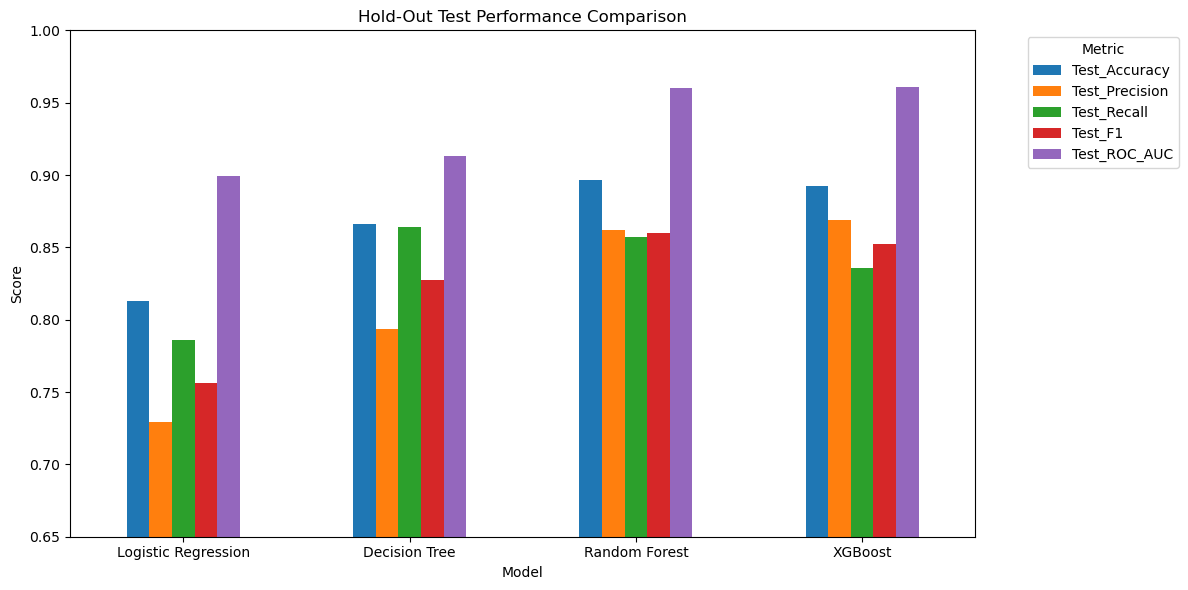

In [10]:
test_plot = test_comparison.set_index("Model")

ax = test_plot.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Hold-Out Test Performance Comparison")
plt.ylabel("Score")
plt.xlabel("Model")

plt.ylim(0.65, 1.00)

plt.xticks(rotation=0)

plt.legend(
    title="Metric",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

## 8. Classification Error Analysis

The confusion-matrix errors of the four candidate models are compared to understand the practical types of mistakes made by each model.

Two important errors are considered:

- **False Positive (FP):** The model predicts that a booking will be cancelled, but the booking is actually not cancelled.
- **False Negative (FN):** The model predicts that a booking will not be cancelled, but the booking is actually cancelled.

For hotel cancellation prediction, False Negatives are particularly important because they represent actual cancellations that were not identified by the system.

However, both error types are considered when selecting the final model.

In [11]:
error_comparison = comparison_df[
    [
        "Model",
        "TN",
        "FP",
        "FN",
        "TP"
    ]
].copy()

error_comparison["Total_Errors"] = (
    error_comparison["FP"]
    + error_comparison["FN"]
)

error_comparison.round(0)

,Model,TN,FP,FN,TP,Total_Errors
0,Logistic Regression,12454,2579,1895,6950,4474
1,Decision Tree,13043,1990,1202,7643,3192
2,Random Forest,13819,1214,1261,7584,2475
3,XGBoost,13917,1116,1452,7393,2568


### False Positive and False Negative Comparison

False Positives and False Negatives are visualized separately to compare the error behaviour of the four candidate models.

In the hotel booking cancellation scenario:

- A False Positive occurs when the model predicts cancellation, but the booking is actually not cancelled.
- A False Negative occurs when the model predicts no cancellation, but the booking actually cancels.

False Negatives are particularly important because they represent actual cancellations that the prediction system failed to identify.

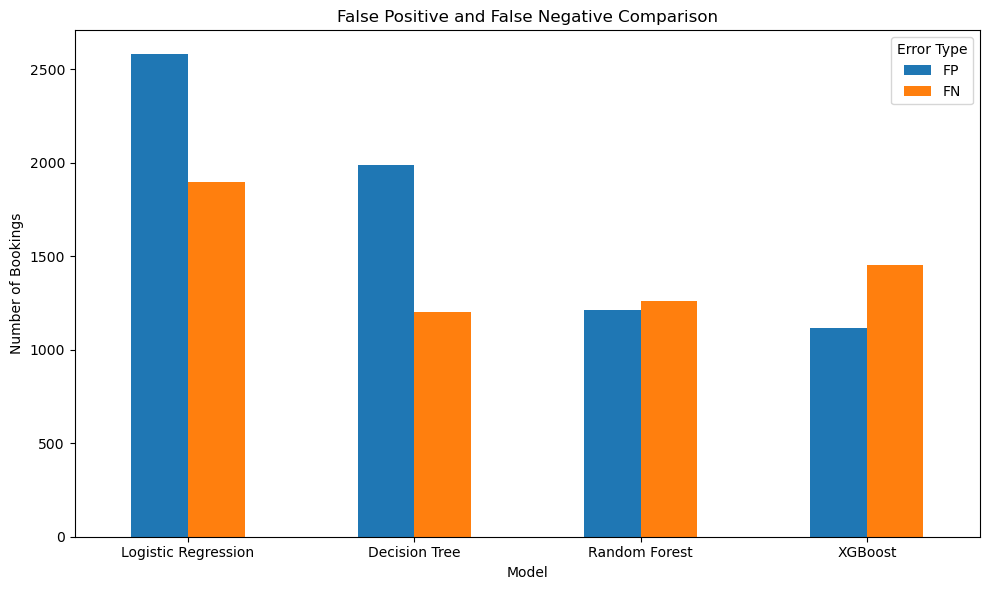

In [12]:
error_plot = error_comparison[
    [
        "Model",
        "FP",
        "FN"
    ]
].set_index("Model")

error_plot.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title(
    "False Positive and False Negative Comparison"
)

plt.ylabel("Number of Bookings")
plt.xlabel("Model")

plt.xticks(rotation=0)

plt.legend(
    title="Error Type"
)

plt.tight_layout()
plt.show()

## 9. Random Forest vs XGBoost Head-to-Head Comparison

Random Forest and XGBoost are the two strongest overall candidates based on the hold-out test results.

Random Forest achieved the highest Test Accuracy and Test F1-score, while XGBoost achieved the highest Test Precision and Test ROC-AUC.

The two models are therefore compared directly using predictive performance, classification errors, and generalization consistency before selecting the final model.

In [13]:
top_models = comparison_df[
    comparison_df["Model"].isin(
        ["Random Forest", "XGBoost"]
    )
][
    [
        "Model",
        "Test_Accuracy",
        "Test_Precision",
        "Test_Recall",
        "Test_F1",
        "Test_ROC_AUC",
        "FP",
        "FN"
    ]
].copy()

top_models["Total_Errors"] = (
    top_models["FP"]
    + top_models["FN"]
)

top_models.round(4)

,Model,Test_Accuracy,Test_Precision,Test_Recall,Test_F1,Test_ROC_AUC,FP,FN,Total_Errors
2,Random Forest,0.8963,0.8620,0.8574,0.8597,0.9599,1214,1261,2475
3,XGBoost,0.8925,0.8688,0.8358,0.8520,0.9611,1116,1452,2568


### Head-to-Head Difference Analysis

The performance differences between Random Forest and XGBoost are calculated directly.

Positive values in the predictive-performance differences below indicate an advantage for Random Forest.

The classification-error differences are interpreted separately because lower error counts are preferred.

This comparison provides additional evidence for selecting the final model.

In [14]:
rf = comparison_df[
    comparison_df["Model"] == "Random Forest"
].iloc[0]

xgb = comparison_df[
    comparison_df["Model"] == "XGBoost"
].iloc[0]

rf_vs_xgb = pd.DataFrame({
    "Criterion": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC-AUC",
        "False Positives",
        "False Negatives",
        "Total Errors"
    ],

    "Random Forest": [
        rf["Test_Accuracy"],
        rf["Test_Precision"],
        rf["Test_Recall"],
        rf["Test_F1"],
        rf["Test_ROC_AUC"],
        rf["FP"],
        rf["FN"],
        rf["FP"] + rf["FN"]
    ],

    "XGBoost": [
        xgb["Test_Accuracy"],
        xgb["Test_Precision"],
        xgb["Test_Recall"],
        xgb["Test_F1"],
        xgb["Test_ROC_AUC"],
        xgb["FP"],
        xgb["FN"],
        xgb["FP"] + xgb["FN"]
    ]
})

rf_vs_xgb.round(4)

,Criterion,Random Forest,XGBoost
0,Accuracy,0.8963,0.8925
1,Precision,0.8620,0.8688
2,Recall,0.8574,0.8358
3,F1,0.8597,0.8520
4,ROC-AUC,0.9599,0.9611
5,False Positives,1214.0000,1116.0000
6,False Negatives,1261.0000,1452.0000
7,Total Errors,2475.0000,2568.0000


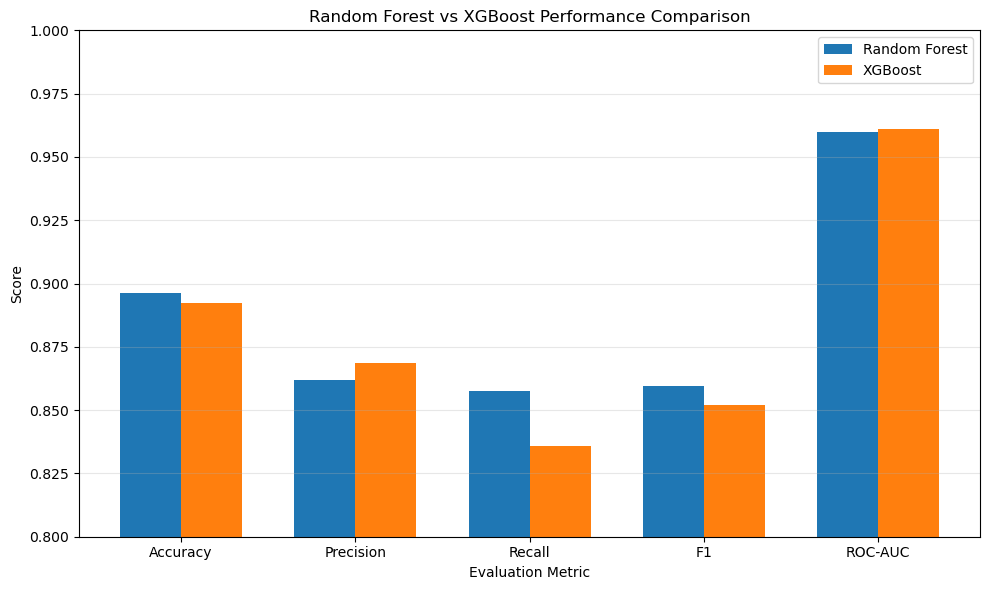

In [15]:
import matplotlib.pyplot as plt
import numpy as np

metrics = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']

rf_scores = [0.8963, 0.8620, 0.8574, 0.8597, 0.9599]
xgb_scores = [0.8925, 0.8688, 0.8358, 0.8520, 0.9611]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(x - width/2, rf_scores, width, label='Random Forest')
plt.bar(x + width/2, xgb_scores, width, label='XGBoost')

plt.xlabel('Evaluation Metric')
plt.ylabel('Score')
plt.title('Random Forest vs XGBoost Performance Comparison')

plt.xticks(x, metrics)
plt.ylim(0.80, 1.00)

plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 10. Final Candidate Analysis

Random Forest and XGBoost demonstrated the strongest overall predictive performance among the four candidate models.

### Random Forest strengths

- Higher hold-out Accuracy: 89.63%
- Higher Recall: 85.74%
- Higher F1-score: 85.97%
- Fewer False Negatives: 1,261
- Fewer total classification errors: 2,475
- Smaller overall cross-validation-to-test generalization gap than XGBoost

### XGBoost strengths

- Higher Precision: 86.88%
- Slightly higher ROC-AUC: 96.11%
- Fewer False Positives: 1,116

The ROC-AUC difference between Random Forest and XGBoost is very small.

Random Forest provides higher Recall and F1-score and misses fewer actual cancellations. In the hotel booking cancellation scenario, missed cancellations are important because a False Negative represents an actual cancellation that the system failed to identify.

Therefore, Random Forest provides the stronger overall predictive balance for the current project objective.

## 12. Final Model Selection

### Selected Final Model: Random Forest

After systematically comparing Logistic Regression, Decision Tree, Random Forest, and XGBoost, Random Forest is selected as the final candidate for deployment.

The final selection is based on the combined evaluation evidence rather than a single metric.

### Random Forest final hold-out performance

- Accuracy: 89.63%
- Precision: 86.20%
- Recall: 85.74%
- F1-score: 85.97%
- ROC-AUC: 95.99%
- False Positives: 1,214
- False Negatives: 1,261
- Total classification errors: 2,475

Random Forest achieved the highest Accuracy and F1-score among the four candidate models.

Although XGBoost achieved slightly higher Precision and ROC-AUC, Random Forest achieved higher Recall, higher F1-score, fewer False Negatives, fewer total classification errors, and a smaller overall cross-validation-to-test generalization gap than XGBoost.

The higher Recall is particularly relevant to the project because False Negatives represent actual cancellations that were not identified by the prediction system.

Therefore, Random Forest is selected as the final model because it provides the strongest overall balance of predictive performance, cancellation detection, and generalization.

The final deployment pipeline will be prepared separately before backend integration.

## 13. Save Final Model Comparison Results

The standardized four-model comparison table is saved for reporting, final model justification, and later project documentation.

In [16]:
comparison_df.to_csv(
    "../results/final_model_comparison.csv",
    index=False
)

print(
    "Final model comparison saved successfully."
)

Final model comparison saved successfully.
